In [1]:
import sklearn
import pandas
import numpy

print(
    f"✅ scikit-learn {sklearn.__version__} | "
    f"pandas {pandas.__version__} | "
    f"numpy {numpy.__version__}"
)

✅ scikit-learn 1.6.1 | pandas 2.2.2 | numpy 2.0.2


In [2]:
# ============================================================
# CELDA 1: Dataset MINEDU — ejecutar sin modificar
# ============================================================

import pandas as pd
import numpy as np

from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)

N = 1200

colegios = [
    "José María Arguedas",
    "Colegio Nacional Lima",
    "IE Santa Rosa",
    "IE San Marcos",
    "IE Héroes del Cenepa"
]

distritos = [
    "Ate",
    "SJL",
    "Villa El Salvador",
    "Los Olivos",
    "Miraflores",
    "Barranco",
    "Comas",
    "Callao"
]

df = pd.DataFrame({
    "id_alumno": [f"ALU{i:04d}" for i in range(1, N + 1)],
    "colegio": np.random.choice(colegios, N),
    "distrito": np.random.choice(distritos, N),
    "asistencia_pct": np.round(np.random.beta(8, 2, N) * 100, 1),
    "promedio_notas": np.round(
        np.random.normal(12.5, 3.2, N).clip(0, 20),
        1
    ),
    "cursos_reprobados": np.random.randint(0, 7, N),
    "trabaja": np.random.choice([0, 1], N, p=[0.75, 0.25]),
    "distancia_km": np.round(np.random.exponential(8, N), 1),
    "tiene_internet": np.random.choice([0, 1], N, p=[0.40, 0.60]),
    "cambios_colegio": np.random.choice(
        [0, 1, 2, 3],
        N,
        p=[0.7, 0.15, 0.1, 0.05]
    ),
    "nivel_ses": np.random.choice(
        ["A/B", "C", "D/E"],
        N,
        p=[0.20, 0.40, 0.40]
    )
})

prob_abandono = (
    0.02
    + (1 - df["asistencia_pct"] / 100) * 0.40
    + df["cursos_reprobados"] * 0.08
    + df["trabaja"] * 0.12
    + df["cambios_colegio"] * 0.06
    - (df["promedio_notas"] - 10) * 0.02
    - df["tiene_internet"] * 0.04
).clip(0.01, 0.90)

df["abandono"] = (
    np.random.random(N) < prob_abandono
).astype(int)

print(f"✅ Dataset MINEDU: {len(df):,} estudiantes")
print(f"📊 Tasa de abandono: {df['abandono'].mean():.1%}")
print("\nPrimeras 5 filas:")

df.head()

✅ Dataset MINEDU: 1,200 estudiantes
📊 Tasa de abandono: 33.0%

Primeras 5 filas:


,id_alumno,colegio,distrito,asistencia_pct,promedio_notas,cursos_reprobados,trabaja,distancia_km,tiene_internet,cambios_colegio,nivel_ses,abandono
0,ALU0001,IE San Marcos,Barranco,91.2,12.6,4,1,0.5,1,1,C,1
1,ALU0002,IE Héroes del Cenepa,Callao,64.5,9.3,3,0,1.5,0,0,C,1
2,ALU0003,IE Santa Rosa,SJL,74.2,5.1,4,0,3.0,1,0,C,1
3,ALU0004,IE Héroes del Cenepa,Los Olivos,92.2,14.6,0,0,3.1,0,0,C,0
4,ALU0005,IE Héroes del Cenepa,Barranco,67.9,20.0,0,0,8.6,0,1,C,0


In [3]:
# ============================================================
# CELDA 2: Preprocesamiento básico
# ============================================================

from sklearn.preprocessing import LabelEncoder

df_modelo = df.copy()

# Convertir variables categóricas a números
for col in ["colegio", "distrito", "nivel_ses"]:
    le = LabelEncoder()
    df_modelo[col + "_cod"] = le.fit_transform(df_modelo[col])

features = [
    "asistencia_pct",
    "promedio_notas",
    "cursos_reprobados",
    "trabaja",
    "distancia_km",
    "tiene_internet",
    "cambios_colegio",
    "colegio_cod",
    "distrito_cod",
    "nivel_ses_cod"
]

X = df_modelo[features]
y = df_modelo["abandono"]

# Dividir los datos:
# 80% para entrenamiento y 20% para prueba
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"✅ Entrenamiento: {len(X_train)} | Prueba: {len(X_test)}")
print(f"   Abandono en train: {y_train.mean():.1%}")
print(f"   Abandono en test:  {y_test.mean():.1%}")

✅ Entrenamiento: 960 | Prueba: 240
   Abandono en train: 33.0%
   Abandono en test:  32.9%


In [4]:
# ============================================================
# CELDA 3: Entrenar el árbol de decisión
# ============================================================

from sklearn.tree import DecisionTreeClassifier, export_text

arbol = DecisionTreeClassifier(
    max_depth=4,
    min_samples_leaf=15,
    class_weight="balanced",
    random_state=42
)

# Entrenar el modelo
arbol.fit(X_train, y_train)

# Mostrar las reglas aprendidas
print("=== REGLAS DEL ÁRBOL DE DECISIÓN ===")
print(export_text(arbol, feature_names=features))

=== REGLAS DEL ÁRBOL DE DECISIÓN ===
|--- cursos_reprobados <= 2.50
|   |--- promedio_notas <= 12.35
|   |   |--- cambios_colegio <= 0.50
|   |   |   |--- tiene_internet <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- tiene_internet >  0.50
|   |   |   |   |--- class: 0
|   |   |--- cambios_colegio >  0.50
|   |   |   |--- tiene_internet <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- tiene_internet >  0.50
|   |   |   |   |--- class: 0
|   |--- promedio_notas >  12.35
|   |   |--- asistencia_pct <= 82.05
|   |   |   |--- asistencia_pct <= 79.75
|   |   |   |   |--- class: 0
|   |   |   |--- asistencia_pct >  79.75
|   |   |   |   |--- class: 0
|   |   |--- asistencia_pct >  82.05
|   |   |   |--- promedio_notas <= 12.95
|   |   |   |   |--- class: 0
|   |   |   |--- promedio_notas >  12.95
|   |   |   |   |--- class: 0
|--- cursos_reprobados >  2.50
|   |--- trabaja <= 0.50
|   |   |--- asistencia_pct <= 76.85
|   |   |   |--- distancia_km <= 9.85
|   |   |   |   |--- cl

=== EVALUACIÓN DEL MODELO ===
               precision    recall  f1-score   support

 Continúa (0)       0.81      0.53      0.64       161
En riesgo (1)       0.44      0.75      0.55        79

     accuracy                           0.60       240
    macro avg       0.62      0.64      0.60       240
 weighted avg       0.69      0.60      0.61       240



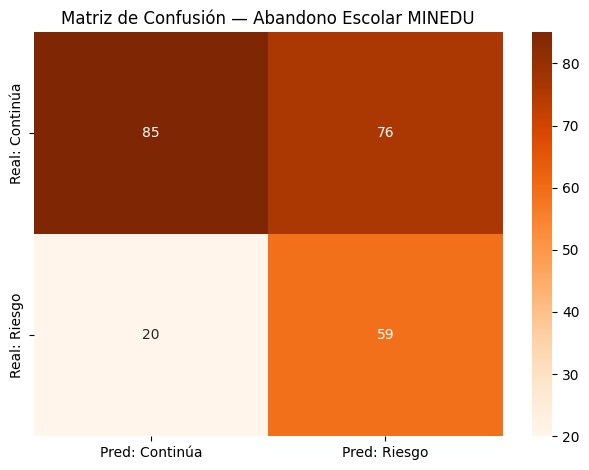

In [5]:
# ============================================================
# CELDA 4: Evaluación del modelo
# ============================================================

# Realizar predicciones
y_pred = arbol.predict(X_test)

# Mostrar métricas
print("=== EVALUACIÓN DEL MODELO ===")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Continúa (0)", "En riesgo (1)"],
        zero_division=0
    )
)

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Oranges',
    xticklabels=["Pred: Continúa", "Pred: Riesgo"],
    yticklabels=["Real: Continúa", "Real: Riesgo"]
)

plt.title("Matriz de Confusión — Abandono Escolar MINEDU")
plt.tight_layout()
plt.show()

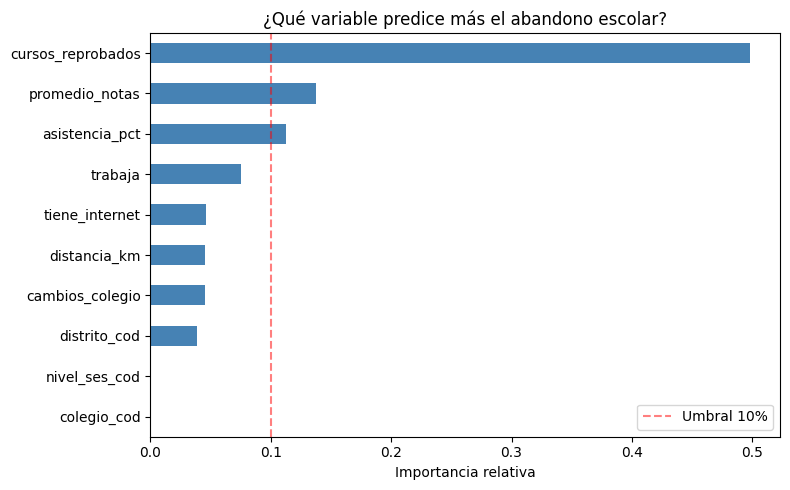


Top 3 variables más importantes:
cursos_reprobados    0.498126
promedio_notas       0.137400
asistencia_pct       0.112736
dtype: float64


In [7]:
# ============================================================
# CELDA 5: Importancia de variables
# ============================================================

importancias = pd.Series(
    arbol.feature_importances_,
    index=features
).sort_values(ascending=True)

importancias.plot(
    kind="barh",
    color="steelblue",
    figsize=(8,5)
)

plt.title("¿Qué variable predice más el abandono escolar?")
plt.xlabel("Importancia relativa")
plt.axvline(
    x=0.10,
    color="red",
    linestyle="--",
    alpha=0.5,
    label="Umbral 10%"
)

plt.legend()
plt.tight_layout()
plt.show()

print("\nTop 3 variables más importantes:")
print(importancias.tail(3)[::-1])

In [8]:
# ============================================================
# CELDA 6: Respuestas del laboratorio
# ============================================================

pregunta_1 = """
Según el gráfico de importancia de variables (Celda 5):

Respuesta:
La variable que más predice el abandono escolar es la cursos_reprobados

Tiene sentido porque un estudiante con baja asistencia tiene mayor
probabilidad de abandonar sus estudios.
"""

pregunta_2 = """
Según la matriz de confusión:

Respuesta:
Los falsos negativos son los estudiantes que realmente estaban en
riesgo, pero el modelo predijo que continuarían estudiando.

Sí es un problema grave porque esos estudiantes no recibirían apoyo
ni tutorías, aumentando la probabilidad de abandono.
"""

pregunta_3 = """
Respuesta:

Si el modelo se utiliza en Pucallpa podría no funcionar igual de bien,
porque fue entrenado únicamente con datos de distritos de Lima.

Esto puede generar un sesgo, ya que las características de los
estudiantes y su contexto pueden ser diferentes.
"""

print(pregunta_1)
print(pregunta_2)
print(pregunta_3)


Según el gráfico de importancia de variables (Celda 5):

Respuesta:
La variable que más predice el abandono escolar es la cursos_reprobados

Tiene sentido porque un estudiante con baja asistencia tiene mayor
probabilidad de abandonar sus estudios.


Según la matriz de confusión:

Respuesta:
Los falsos negativos son los estudiantes que realmente estaban en
riesgo, pero el modelo predijo que continuarían estudiando.

Sí es un problema grave porque esos estudiantes no recibirían apoyo
ni tutorías, aumentando la probabilidad de abandono.


Respuesta:

Si el modelo se utiliza en Pucallpa podría no funcionar igual de bien,
porque fue entrenado únicamente con datos de distritos de Lima.

Esto puede generar un sesgo, ya que las características de los
estudiantes y su contexto pueden ser diferentes.

